## Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [Data Loading & Exploration](#2-data-loading--exploration)
3. [Audio Visualization](#3-audio-visualization)
4. [Feature Engineering](#4-feature-engineering)
5. [Data Pipeline & Preprocessing](#5-data-pipeline--preprocessing)
6. [Classical Baseline Models](#6-classical-baseline-models)
7. [Advanced Models (XGBoost / LightGBM / CatBoost / Neural Network)](#7-advanced-models)
8. [Results & Model Comparison](#8-results--model-comparison)
9. [Key Insights & Conclusions](#9-key-insights--conclusions)

## 1. Setup & Imports
> We load all required libraries up-front so the rest of the notebook runs cleanly.  
> Key libraries:
> - **librosa** — audio loading, feature extraction (MFCCs, chroma, mel-spectrograms, etc.)
> - **scikit-learn** — classical ML models, preprocessing, evaluation
> - **XGBoost / LightGBM / CatBoost** — gradient-boosted tree ensembles
> - **matplotlib / seaborn** — visualisation

In [1]:
# Standard Library 
import os
import warnings
from collections import Counter

warnings.filterwarnings("ignore")

# Data & Math
import numpy as np
import pandas as pd

# Audio Processing
import librosa
import librosa.display

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13})

# Preprocessing & Metrics
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Classical Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
)
from sklearn.neural_network import MLPClassifier

# Boosting Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


## 2. Data Loading & Exploration
> **RAVDESS filename convention:**  
> `03-01-**02**-01-01-01-24.wav`  — the 3rd segment (index 2 in 0-based) encodes the emotion.
>
> | Code | Emotion  | Code | Emotion   |
> |------|----------|------|-----------|
> | 01   | neutral  | 05   | angry     |
> | 02   | calm     | 06   | fearful   |
> | 03   | happy    | 07   | disgust   |
> | 04   | sad      | 08   | surprised |

📂 Total audio files found : 1,440
Sample paths:
   /kaggle/input/datasets/dejolilandry/ravdess/Radvess/Actor_02/03-01-08-01-01-01-02.wav
   /kaggle/input/datasets/dejolilandry/ravdess/Radvess/Actor_02/03-01-01-01-01-01-02.wav
   /kaggle/input/datasets/dejolilandry/ravdess/Radvess/Actor_02/03-01-07-02-01-02-02.wav
Dataset shape : (1440, 2)


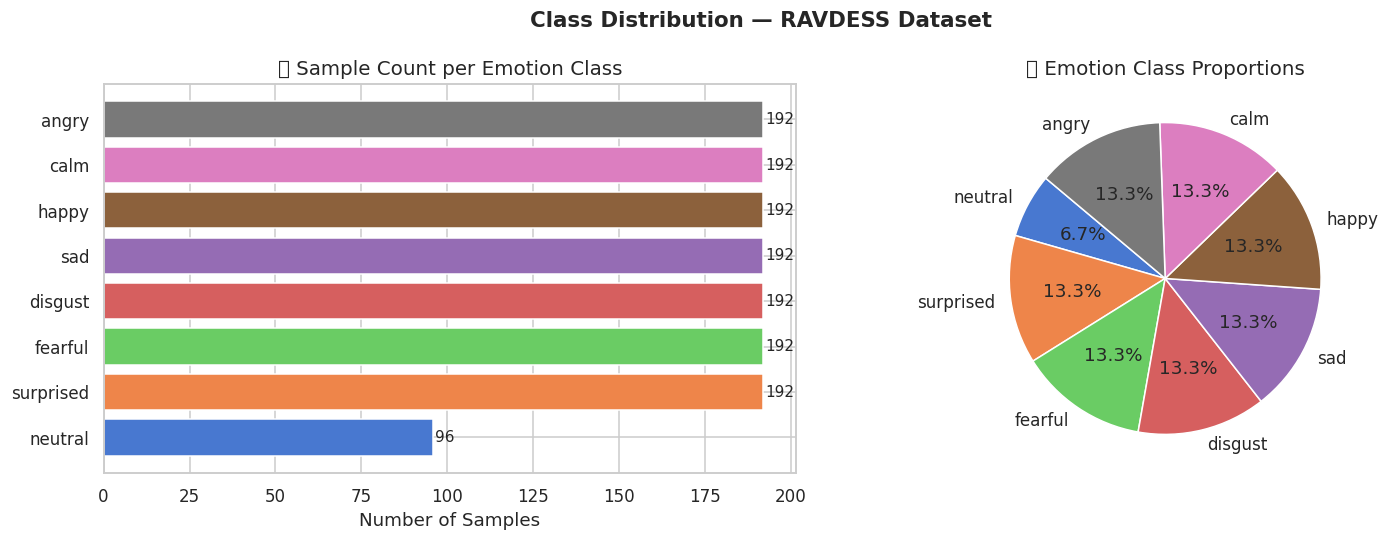

In [2]:
# Collect all .wav file paths
wav_files = []
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith(".wav"):
            wav_files.append(os.path.join(dirname, filename))

print(f"📂 Total audio files found : {len(wav_files):,}")
print("Sample paths:")
for p in wav_files[:3]:
    print("  ", p)

# Map filenames → emotion labels
EMOTIONS_MAP = {
    '01': 'neutral',  '02': 'calm',     '03': 'happy',
    '04': 'sad',      '05': 'angry',    '06': 'fearful',
    '07': 'disgust',  '08': 'surprised'
}

def get_emotion(path: str) -> str:
    """Extract emotion label from RAVDESS filename convention."""
    code = os.path.basename(path).split('-')[2]
    return EMOTIONS_MAP.get(code, 'unknown')

df = pd.DataFrame({
    "path":    wav_files,
    "emotion": [get_emotion(p) for p in wav_files]
})

print(f"Dataset shape : {df.shape}")
df.head()

# Class Distribution
label_counts = df['emotion'].value_counts().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].barh(label_counts.index, label_counts.values,
             color=sns.color_palette("muted", len(label_counts)))
axes[0].set_xlabel("Number of Samples")
axes[0].set_title("📊 Sample Count per Emotion Class")
for i, v in enumerate(label_counts.values):
    axes[0].text(v + 0.5, i, str(v), va='center', fontsize=10)

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index,
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette("muted", len(label_counts)))
axes[1].set_title("🥧 Emotion Class Proportions")

plt.suptitle("Class Distribution — RAVDESS Dataset", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The dataset is well balanced across the eight emotion classes. While the neutral class has roughly half as many samples as the other classes, the imbalance is not significant enough to require oversampling or class weighting.

## 3. Audio Visualization
> Before extracting features, we explore the raw audio signal and its time-frequency representations.
>
> We will visualise **four complementary views** of a single audio clip:
> 1. **Waveform** — raw amplitude over time
> 2. **Spectrogram (STFT)** — frequency energy over time (log scale)
> 3. **Mel Spectrogram** — human-perception-scaled frequency map
> 4. **MFCC** — compact cepstral coefficients most relevant for emotion/speech

In [3]:
# Load a sample file
sample_path = df.iloc[0]["path"]
sample_emotion = df.iloc[0]["emotion"]
signal, sr = librosa.load(sample_path, sr=None)

duration = len(signal) / sr
print(f"🎵 File     : {os.path.basename(sample_path)}")
print(f"   Emotion  : {sample_emotion}")
print(f"   SR       : {sr:,} Hz")
print(f"   Duration : {duration:.2f} s")
print(f"   Samples  : {len(signal):,}")

🎵 File     : 03-01-08-01-01-01-02.wav
   Emotion  : surprised
   SR       : 48,000 Hz
   Duration : 3.54 s
   Samples  : 169,769


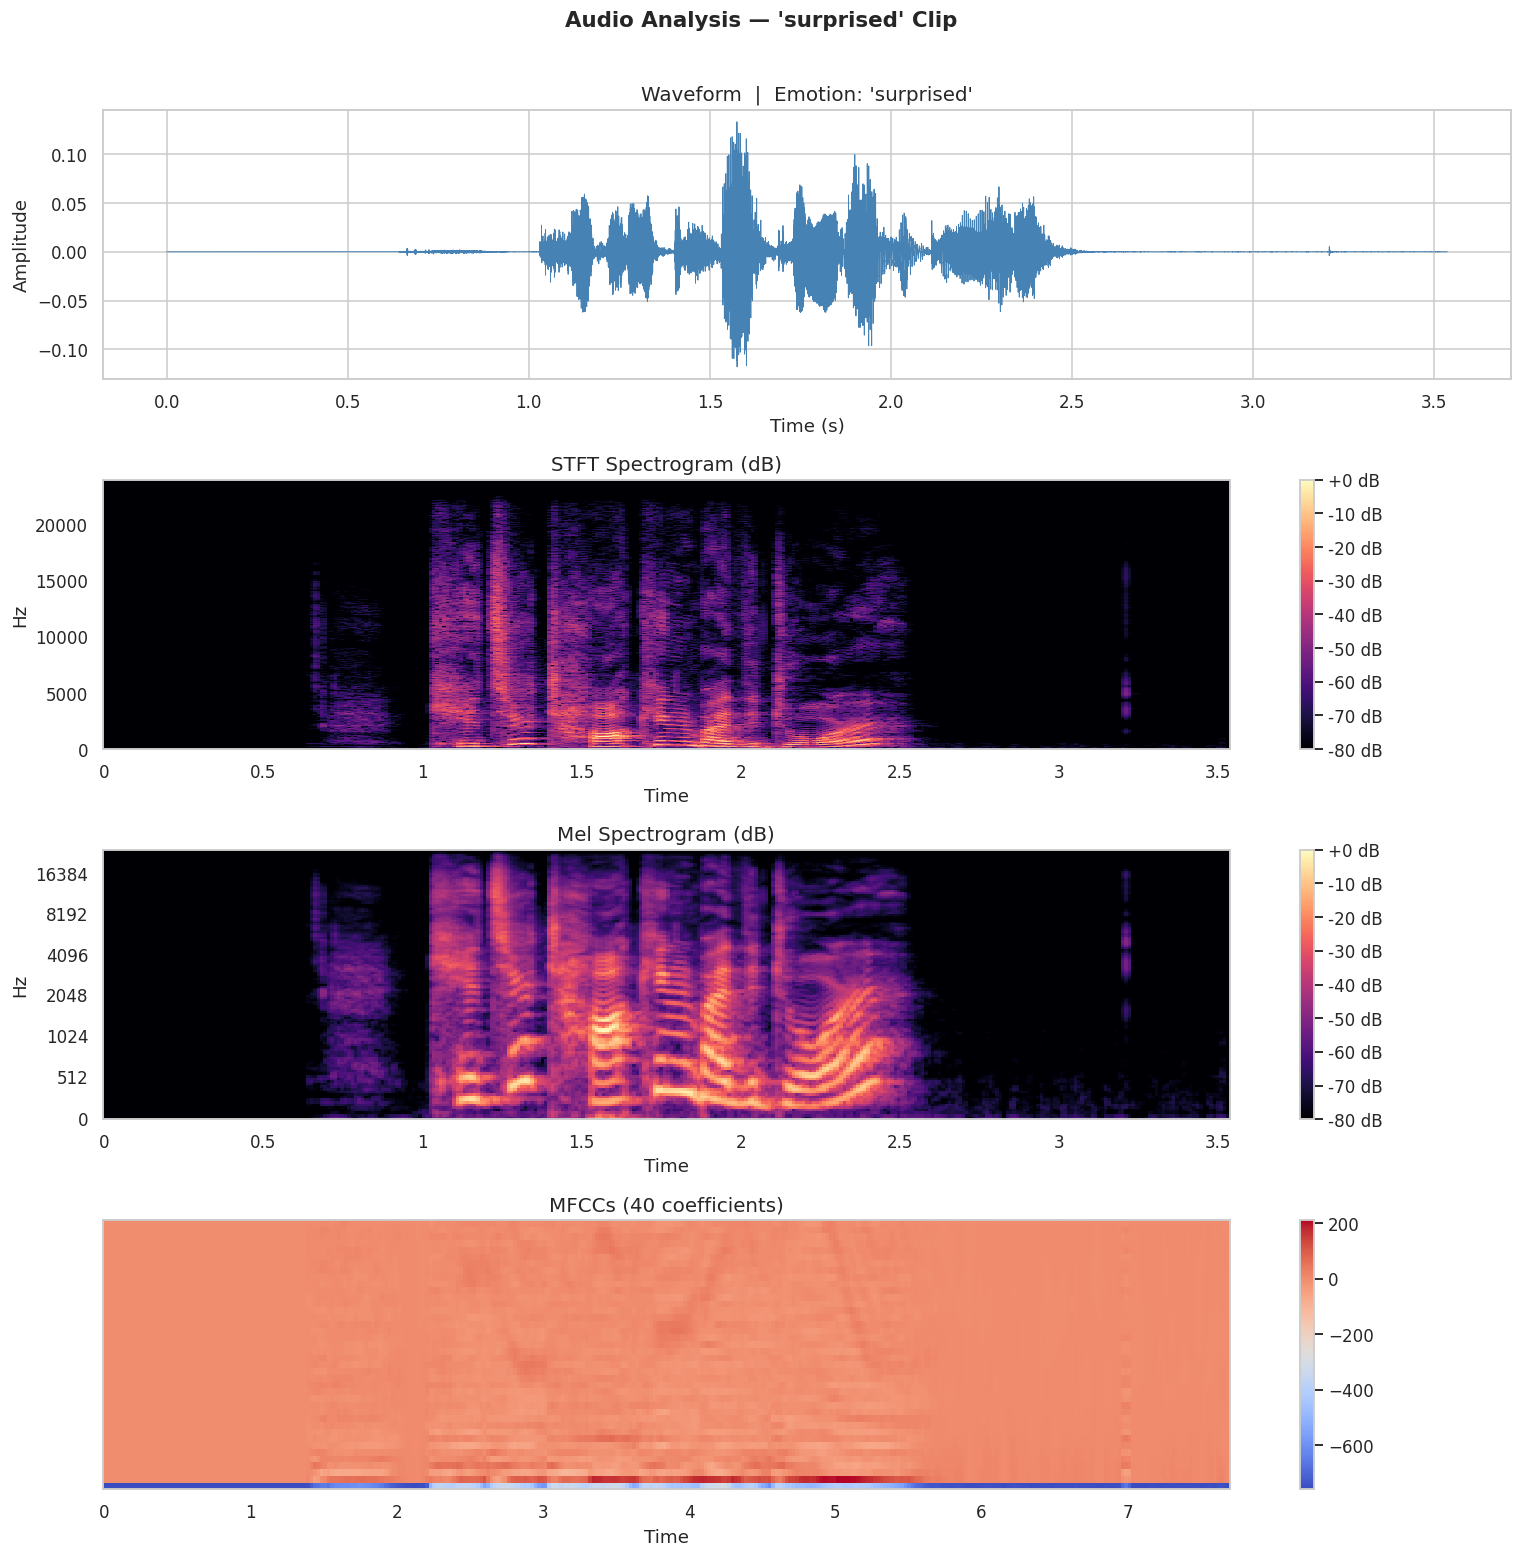

In [4]:
# Four-panel audio visualisation
fig, axes = plt.subplots(4, 1, figsize=(14, 14))

# 1. Waveform
axes[0].plot(np.linspace(0, duration, len(signal)), signal, color='steelblue', lw=0.6)
axes[0].set_title(f"Waveform  |  Emotion: '{sample_emotion}'")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")

# 2. STFT Spectrogram
D = librosa.amplitude_to_db(np.abs(librosa.stft(signal)), ref=np.max)
img2 = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=axes[1])
axes[1].set_title("STFT Spectrogram (dB)")
fig.colorbar(img2, ax=axes[1], format="%+2.0f dB")

# 3. Mel Spectrogram
mel = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=128)
mel_db = librosa.power_to_db(mel, ref=np.max)
img3 = librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[2])
axes[2].set_title("Mel Spectrogram (dB)")
fig.colorbar(img3, ax=axes[2], format="%+2.0f dB")

# 4. MFCCs
mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=40)
img4 = librosa.display.specshow(mfccs, x_axis='time', ax=axes[3])
axes[3].set_title("MFCCs (40 coefficients)")
fig.colorbar(img4, ax=axes[3])

plt.suptitle(f"Audio Analysis — '{sample_emotion}' Clip", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

1. Temporal Energy Distribution (Waveform)
The speech activity is concentrated between approximately 1.0 s and 2.5 s, with silence before and after.
Several high-amplitude peaks appear around 1.5–2.0 s, indicating sudden bursts of vocal energy.
These abrupt increases in amplitude are characteristic of surprise, where speakers often exhibit rapid changes in loudness and emphasis.
2. Frequency Content (STFT Spectrogram)
The spectrogram shows energy spread across a wide frequency range, extending beyond 15 kHz during active speech regions.
Multiple vertical energy bands indicate rapid spectral transitions and changes in articulation.
Compared to calmer emotions, the signal exhibits stronger high-frequency components, suggesting a more excited and expressive vocal production.
3. Perceptual Frequency Patterns (Mel Spectrogram)
Strong energy concentrations are visible in the lower and mid-frequency bands (roughly 200–3000 Hz), where most speech information resides.
The harmonic structures become more pronounced during the high-energy segments, indicating increased vocal effort.
The varying intensity patterns suggest dynamic pitch and formant movements, commonly associated with surprised speech.
4. MFCC Characteristics
The MFCC representation shows clear temporal variations rather than a stable pattern.
Lower-order coefficients exhibit stronger responses, reflecting changes in the overall spectral envelope.
These fluctuations indicate that the acoustic characteristics of the utterance vary significantly over time, which is expected for expressive emotions such as surprise.
5. Emotion-Specific Interpretation
    The acoustic features align well with typical properties of surprised speech:
       - Higher vocal intensity (larger waveform peaks).
       - Broader frequency distribution.
       - Increased spectral variability.
       - Rapid temporal changes in energy and articulation.

These characteristics differentiate surprise from more neutral emotions, which generally exhibit smoother energy contours, lower spectral variability, and more stable MFCC patterns.

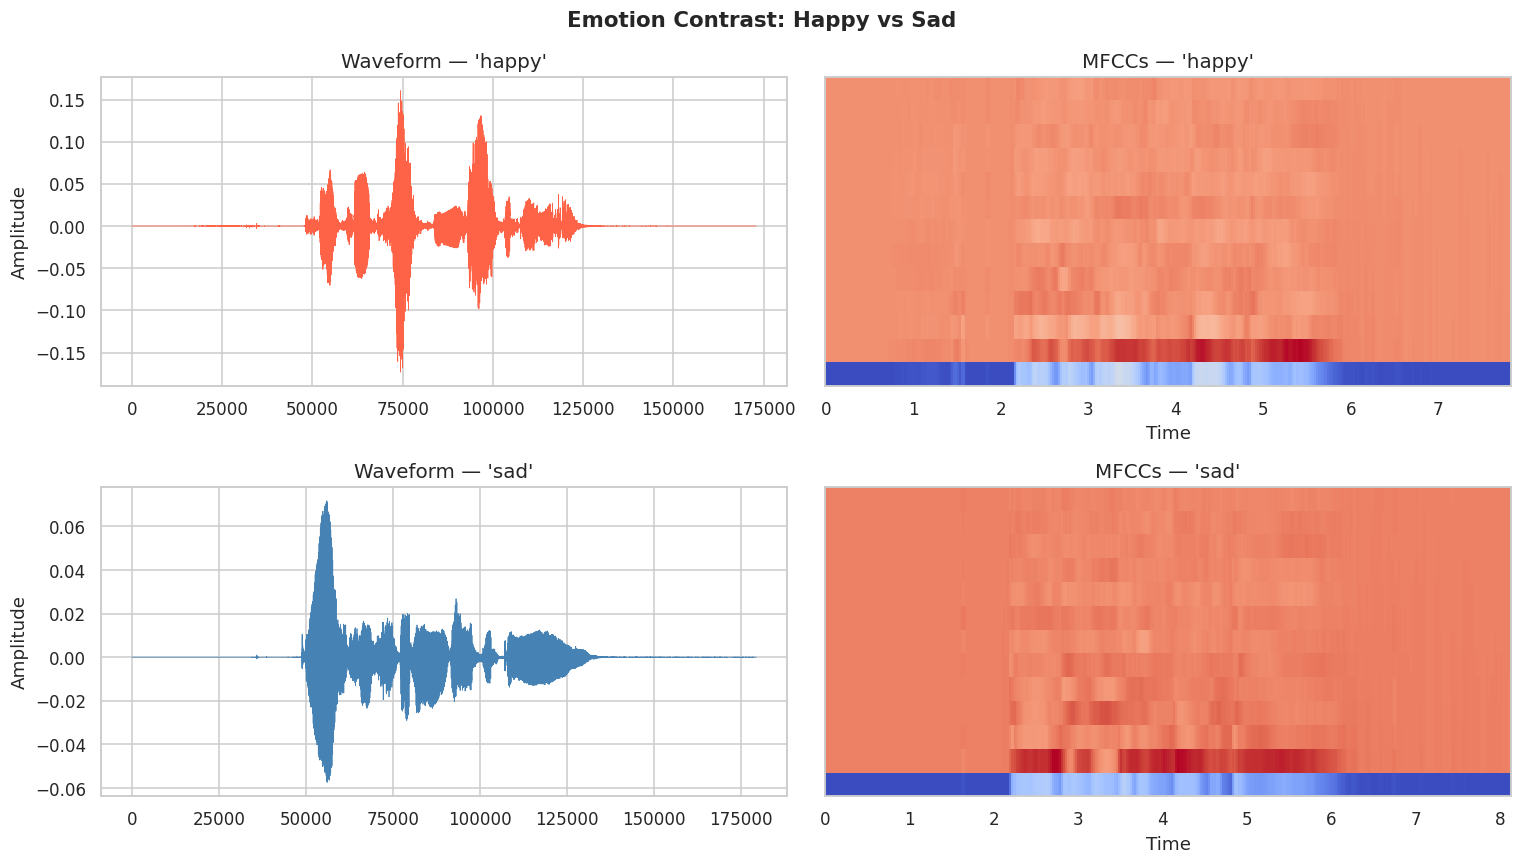

In [5]:
# Compare two contrasting emotions
emotion_a = 'happy'
emotion_b = 'sad'

path_a = df[df['emotion'] == emotion_a].iloc[0]['path']
path_b = df[df['emotion'] == emotion_b].iloc[0]['path']

sig_a, _ = librosa.load(path_a, sr=None)
sig_b, _ = librosa.load(path_b, sr=None)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, (sig, emotion, color) in enumerate([
        (sig_a, emotion_a, 'tomato'),
        (sig_b, emotion_b, 'steelblue')]):
    # Waveform
    axes[i][0].plot(sig, color=color, lw=0.5)
    axes[i][0].set_title(f"Waveform — '{emotion}'")
    axes[i][0].set_ylabel("Amplitude")
    # MFCC
    mf = librosa.feature.mfcc(y=sig, sr=sr, n_mfcc=13)
    librosa.display.specshow(mf, x_axis='time', ax=axes[i][1])
    axes[i][1].set_title(f"MFCCs — '{emotion}'")

plt.suptitle("Emotion Contrast: Happy vs Sad", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The comparison reveals clear acoustic differences between happy and sad speech. The happy utterance exhibits substantially higher amplitude peaks and greater temporal variability, indicating increased vocal intensity and expressive articulation. In contrast, the sad utterance shows lower energy, a smoother amplitude envelope, and more stable MFCC patterns, reflecting a softer and less dynamic vocal delivery. These observations suggest that energy-related features and MFCC dynamics are effective cues for distinguishing between happy and sad emotions in speech.

## 4. Feature Engineering
> We extract a rich, **hand-crafted feature vector** from each audio clip using 9 different audio descriptors.  
> Each descriptor contributes both **mean** and **standard deviation** across frames — capturing central tendency and variability.
>
> | Feature | Dim | What it captures |
> |---------|-----|-----------------|
> | MFCC (40 coefficients) | 80 | Spectral shape / timbre |
> | Chroma STFT (12 bins) | 24 | Pitch class energy |
> | Mel Spectrogram (128 bins) | 256 | Perceptual frequency power |
> | Spectral Contrast (7 bands) | 14 | Peak/valley energy ratio |
> | Zero Crossing Rate | 2 | Signal noisiness / voicing |
> | RMS Energy | 2 | Overall loudness |
> | Spectral Centroid | 2 | Brightness |
> | Spectral Bandwidth | 2 | Spread around centroid |
> | Spectral Rolloff | 2 | High-frequency energy limit |
> | **Total** | **384** | |


In [6]:
def extract_features(path: str) -> np.ndarray:
    """
    Extract a 384-dimensional feature vector from a .wav file.

    For each audio descriptor we compute:
      - axis-wise mean  (central tendency)
      - axis-wise std   (variability / expressiveness)

    Returns
    -------
    np.ndarray of shape (384,) with dtype float32
    """
    signal, sr = librosa.load(path, sr=None)
    features = []

    def add_stats(feature_matrix: np.ndarray):
        """Append mean + std along time axis (axis=1)."""
        features.extend(np.mean(feature_matrix, axis=1).tolist())
        features.extend(np.std(feature_matrix,  axis=1).tolist())

    # 1. MFCC — 40 coefficients × 2 stats = 80 features
    add_stats(librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=40))

    # 2. Chroma STFT — 12 bins × 2 = 24 features
    add_stats(librosa.feature.chroma_stft(y=signal, sr=sr))

    # 3. Mel Spectrogram — 128 bins × 2 = 256 features
    mel = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=128)
    add_stats(librosa.power_to_db(mel))

    # 4. Spectral Contrast — 7 bands × 2 = 14 features
    add_stats(librosa.feature.spectral_contrast(y=signal, sr=sr))

    # 5. Zero Crossing Rate — 1 × 2 = 2 features
    add_stats(librosa.feature.zero_crossing_rate(signal))

    # 6. RMS Energy — 1 × 2 = 2 features
    add_stats(librosa.feature.rms(y=signal))

    # 7. Spectral Centroid — 1 × 2 = 2 features
    add_stats(librosa.feature.spectral_centroid(y=signal, sr=sr))

    # 8. Spectral Bandwidth — 1 × 2 = 2 features
    add_stats(librosa.feature.spectral_bandwidth(y=signal, sr=sr))

    # 9. Spectral Rolloff — 1 × 2 = 2 features
    add_stats(librosa.feature.spectral_rolloff(y=signal, sr=sr))

    return np.array(features, dtype=np.float32)

In [7]:
# Extract features for all files
print("⏳ Extracting features from all audio files…")

X_list, y_list = [], []
for idx, row in df.iterrows():
    X_list.append(extract_features(row["path"]))
    y_list.append(row["emotion"])

X = np.array(X_list)   # shape: (n_samples, 384)
y = np.array(y_list)

print(f"\n✅ Feature matrix shape : {X.shape}")
print(f"   Label vector shape   : {y.shape}")
print(f"   Feature dimensionality: {X.shape[1]} features per sample")

⏳ Extracting features from all audio files…

✅ Feature matrix shape : (1440, 384)
   Label vector shape   : (1440,)
   Feature dimensionality: 384 features per sample


The extracted features capture complementary aspects of speech, including vocal timbre (MFCCs), pitch information (Chroma), frequency-energy distribution (Mel Spectrogram), spectral characteristics (Contrast, Centroid, Bandwidth, Rolloff), and temporal energy dynamics (ZCR and RMS), providing a comprehensive representation for emotion recognition.

| Feature                                        | Description                                                                                                                                 |
| ---------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------- |
| **MFCC (Mel-Frequency Cepstral Coefficients)** | Captures the overall spectral shape and timbre of speech, often considered the most informative feature for speech and emotion recognition. |
| **Chroma STFT**                                | Represents the distribution of energy across the 12 pitch classes, capturing pitch-related characteristics of the audio.                    |
| **Mel Spectrogram**                            | Describes how audio energy is distributed across frequencies over time using a scale that approximates human hearing.                       |
| **Spectral Contrast**                          | Measures the difference between spectral peaks and valleys, providing information about the richness and clarity of the sound.              |
| **Zero Crossing Rate (ZCR)**                   | Counts how frequently the audio signal changes sign, indicating the presence of noisy, sharp, or unvoiced sounds.                           |
| **RMS Energy**                                 | Measures the overall loudness or energy of the audio signal.                                                                                |
| **Spectral Centroid**                          | Indicates the center of mass of the frequency spectrum and is commonly associated with the perceived brightness of a sound.                 |
| **Spectral Bandwidth**                         | Measures the spread of frequencies around the spectral centroid, reflecting the complexity of the spectrum.                                 |
| **Spectral Rolloff**                           | Represents the frequency below which most of the signal energy is concentrated, helping distinguish between low- and high-frequency sounds. |
| **Mean**                                       | Captures the average value of each feature across the entire audio clip, representing its overall characteristic.                           |
| **Standard Deviation (Std)**                   | Measures the variability of each feature over time, reflecting the dynamic and expressive nature of the speech signal.                      |

Feature Matrix Statistics:
               mean          std          min           max
count    384.000000   384.000000   384.000000    384.000000
mean      74.987008    17.124763    15.102784    119.337602
std      782.060045   107.256532   372.192049   1037.299206
min     -617.135437     0.012293  -873.242310   -333.377960
25%      -50.653721     1.863354   -74.948030    -22.998612
50%        0.786914     2.381384     0.196181     12.328185
75%       13.963399     9.471994     6.954374     21.847839
max    10841.660156  1503.046021  4997.524902  14629.598633


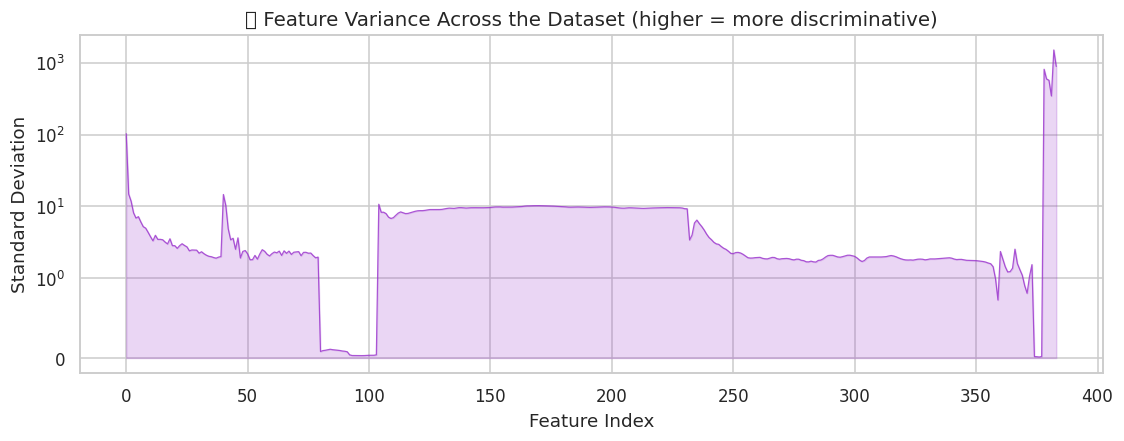

In [8]:
# Feature statistics overview
feat_df = pd.DataFrame(X)

print("Feature Matrix Statistics:")
print(feat_df.describe().T[['mean','std','min','max']].describe())

# Visualise feature variance distribution
plt.figure(figsize=(12, 4))
plt.plot(feat_df.std(), color='darkorchid', lw=0.8, alpha=0.8)
plt.fill_between(range(feat_df.shape[1]), feat_df.std(), alpha=0.2, color='darkorchid')
plt.xlabel("Feature Index")
plt.ylabel("Standard Deviation")
plt.title("📈 Feature Variance Across the Dataset (higher = more discriminative)")
plt.yscale('symlog', linthresh=1.0) 
plt.show()

Since the feature vector is ordered as:

| Index Range | Feature                 |
| ----------- | ----------------------- |
| 0–79        | MFCC (40 mean + 40 std) |
| 80–103      | Chroma                  |
| 104–359     | Mel Spectrogram         |
| 360–373     | Spectral Contrast       |
| 374–375     | ZCR                     |
| 376–377     | RMS                     |
| 378–379     | Spectral Centroid       |
| 380–381     | Spectral Bandwidth      |
| 382–383     | Spectral Rolloff        |

1. MFCCs (0–79)

* Variance ranges roughly from **2 to 10**.
* One visible spike around coefficient ~40.
* Indicates MFCCs vary meaningfully across speakers and emotions.
* Good sign since MFCCs are usually among the strongest SER features.

**Interpretation**

> MFCC features exhibit moderate-to-high variability, suggesting they capture discriminative spectral characteristics associated with different emotional states.

2. Chroma (80–103)

* Variance drops close to **0.1**.
* Much lower than MFCCs and Mel features.

**Interpretation**

> Chroma features contribute less variation across samples, indicating that pitch-class information may be less informative for this speech emotion dataset.

3. Mel Spectrogram (104–359)

This is the most interesting section.

* Variance stays remarkably stable around **8–10**.
* Large contiguous block of highly variable features.
* Indicates many Mel bins respond differently across emotions.

**Interpretation**

> Mel-spectrogram features show consistently high variance across the dataset, suggesting that frequency-energy distributions are among the most informative representations for distinguishing emotional speech.

This aligns with why CNNs on Mel spectrograms often perform very well.

4. Spectral Contrast (360–373)

* Variance roughly **1–3**.
* Lower than Mel features but still non-negligible.

**Interpretation**

> Spectral contrast captures complementary information about spectral structure and contributes additional discrimination beyond MFCCs and Mel features.

5. ZCR and RMS (374–377)

* Small fluctuations.
* Variance around **1–3**.

**Interpretation**

> Temporal energy and noisiness characteristics vary across emotions but contribute less strongly than spectral representations.

6. Spectral Centroid, Bandwidth, and Rolloff (378–383)

These are the giant spikes.

* Centroid ≈ hundreds
* Bandwidth ≈ hundreds
* Rolloff ≈ thousands

These dominate because they are measured directly in **Hz**.

**Important**
These spikes do **not** mean these features are automatically the best predictors.They simply have larger numeric units. After normalization their magnitude advantage disappears.

> The log-scaled variance plot reveals that Mel-spectrogram and MFCC features exhibit the most consistent variability across the dataset, indicating that spectral information carries the strongest emotional cues. Chroma features show comparatively low variance, while spectral centroid, bandwidth, and rolloff display extremely high variance due to their frequency-based units rather than necessarily higher discriminative power. These observations further justify the use of feature standardization before model training.

## 5. Data Pipeline & Preprocessing
> A clean, reproducible pipeline in four stages:
>
> ```
> Features (X)  ──►  Train / Test Split  ──►  StandardScaler  ──►  Label Encoding
> ```
>
> **Design decisions:**
> - `stratify=y` ensures each split has the same class proportions
> - `StandardScaler` is fitted **only on train** to prevent data leakage
> - `LabelEncoder` converts string labels → integer class indices for models


In [9]:
# Stage 1: Train / Test Split (80/20, stratified)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("── Split Summary ──────────────────────────────────")
print(f"  Train samples : {X_train_raw.shape[0]:,}  ({X_train_raw.shape[0]/len(X):.0%})")
print(f"  Test  samples : {X_test_raw.shape[0]:,}   ({X_test_raw.shape[0]/len(X):.0%})")
print(f"  Feature dims  : {X_train_raw.shape[1]}")

── Split Summary ──────────────────────────────────
  Train samples : 1,152  (80%)
  Test  samples : 288   (20%)
  Feature dims  : 384


In [10]:
# Stage 2: Label Encoding
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test  = le.transform(y_test_raw)

print("Label mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

Label mapping:
  0 → angry
  1 → calm
  2 → disgust
  3 → fearful
  4 → happy
  5 → neutral
  6 → sad
  7 → surprised


In [11]:
# Stage 3: Feature Scaling (StandardScaler — no data leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)   # fit+transform on train only
X_test  = scaler.transform(X_test_raw)         # transform only on test

print(f"X_train — mean≈{X_train.mean():.4f}  std≈{X_train.std():.4f}")
print(f"X_test  — mean≈{X_test.mean():.4f}   std≈{X_test.std():.4f}")

X_train — mean≈-0.0000  std≈1.0000
X_test  — mean≈0.0008   std≈0.9775


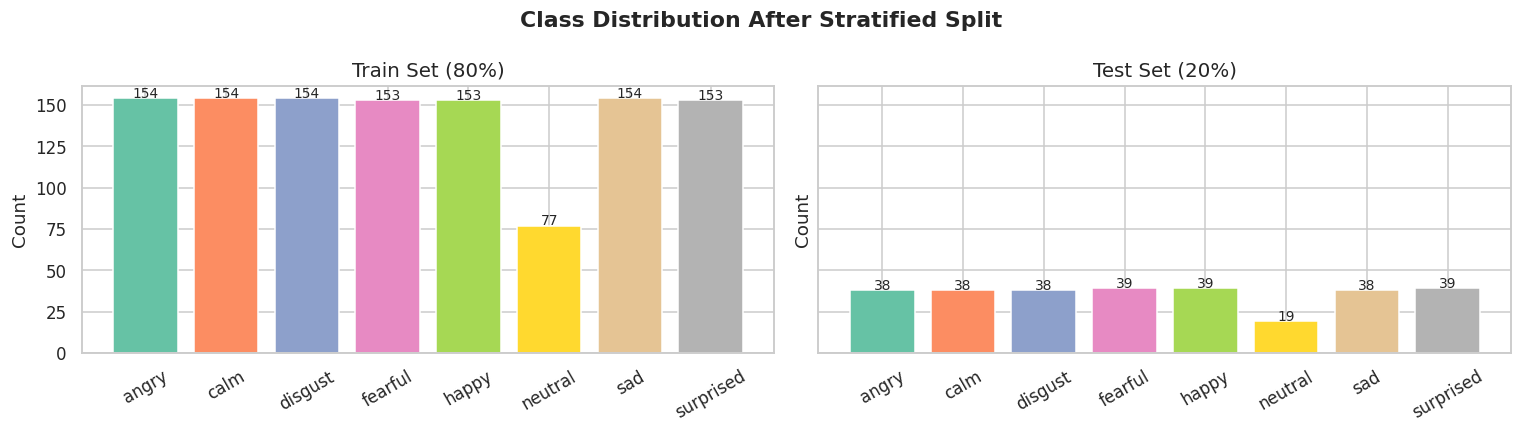

In [12]:
# Stage 4: Class Distribution Validation
train_counts = Counter(y_train_raw)
test_counts  = Counter(y_test_raw)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
emotions = le.classes_
colors = sns.color_palette("Set2", len(emotions))

for ax, counts, title in zip(axes,
                              [train_counts, test_counts],
                              ["Train Set (80%)", "Test Set (20%)"]):
    vals = [counts[e] for e in emotions]
    ax.bar(emotions, vals, color=colors)
    ax.set_title(title)
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=30)
    for j, v in enumerate(vals):
        ax.text(j, v + 0.3, str(v), ha='center', fontsize=9)

plt.suptitle("Class Distribution After Stratified Split", fontweight='bold')
plt.tight_layout()
plt.show()

Stratification keeps proportions identical across train and test, ensuring no class is over- or under-represented in evaluation.

## 6. Classical Baseline Models
> We benchmark **5 classical classifiers** before moving to advanced ensembles.
>
> | Model | Strength | Weakness |
> |-------|----------|---------|
> | Logistic Regression | Fast, interpretable | Linear boundary only |
> | Linear SVM | Good on high-dim data | No non-linearity |
> | RBF SVM | Strong non-linear classifier | Slow on large data |
> | LDA | Low-dim projection | Assumes Gaussian classes |
> | Gaussian Naïve Bayes | Very fast baseline | Feature independence assumption |
>
> **Overfitting mitigation**: regularised C values, max_iter tuned.


In [13]:
# Define Classical Baselines
baseline_models = {
    "Logistic Regression": LogisticRegression(
        C=0.5, max_iter=2000, random_state=42
    ),
    "Linear SVM": SVC(
        kernel="linear", C=0.5,
        probability=True, random_state=42
    ),
    "RBF SVM": SVC(
        kernel="rbf", C=1.0, gamma="scale",
        probability=True, random_state=42
    ),
    "LDA": LinearDiscriminantAnalysis(),
    "Gaussian Naïve Bayes": GaussianNB(),
}

# Evaluation helper
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, results_list):
    """Fit, predict, and collect metrics. Prints a concise summary."""
    model.fit(X_tr, y_tr)
    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)

    tr_acc = accuracy_score(y_tr, y_tr_pred)
    te_acc = accuracy_score(y_te, y_te_pred)
    gap    = tr_acc - te_acc  # overfitting gap

    results_list.append({
        "Model":          name,
        "Train Acc":      tr_acc,
        "Test Acc":       te_acc,
        "Overfit Gap":    gap,
    })

    print(f"  Train: {tr_acc:.2%}  |  Test: {te_acc:.2%}  |  Gap: {gap:+.2%}")
    return model, y_te_pred

# Run baselines
all_results   = []
all_preds     = {}
trained_models = {}

print("=" * 58)
print("  CLASSICAL BASELINE MODELS")
print("=" * 58)
for name, model in baseline_models.items():
    print(f"\n▶ {name}")
    m, preds = evaluate_model(name, model, X_train, y_train, X_test, y_test, all_results)
    trained_models[name] = m
    all_preds[name]      = preds

  CLASSICAL BASELINE MODELS

▶ Logistic Regression
  Train: 98.18%  |  Test: 68.40%  |  Gap: +29.77%

▶ Linear SVM
  Train: 100.00%  |  Test: 71.18%  |  Gap: +28.82%

▶ RBF SVM
  Train: 81.94%  |  Test: 67.36%  |  Gap: +14.58%

▶ LDA
  Train: 94.97%  |  Test: 62.50%  |  Gap: +32.47%

▶ Gaussian Naïve Bayes
  Train: 38.98%  |  Test: 36.81%  |  Gap: +2.17%


## 7. Advanced Models
> We now apply four sophisticated models with **carefully tuned anti-overfitting parameters**.
>
> ### 7a. Ensemble Tree Models (Random Forest, Extra Trees, Gradient Boosting)
> - Depth limits + minimum leaf constraints reduce variance
> - Subsampling adds stochasticity to prevent memorisation
>
> ### 7b. Gradient Boosted Frameworks
> | Model | Anti-overfit strategy |
> |-------|-----------------------|
> | **XGBoost** | `gamma`, `min_child_weight`, `reg_alpha`, `reg_lambda` |
> | **LightGBM** | `min_child_samples`, `num_leaves`, `reg_alpha`, `reg_lambda` |
> | **CatBoost** | `l2_leaf_reg`, `depth`, `random_strength`, `bagging_temperature` |
>
> ### 7c. MLP Neural Network
> - Smaller hidden layers to constrain capacity
> - L2 regularisation (`alpha`) + early stopping on a held-out validation slice


In [14]:
# Advanced / Ensemble Models
advanced_models = {

    # Tree Ensembles
    "Random Forest": RandomForestClassifier(
        n_estimators=500, max_depth=12,
        min_samples_split=10, min_samples_leaf=5,
        max_features="sqrt", random_state=42, n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=500, max_depth=12,
        min_samples_split=10, min_samples_leaf=5,
        max_features="sqrt", random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.03,
        max_depth=3, subsample=0.8, random_state=42
    ),

    # XGBoost (regularised)
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=4,
        learning_rate=0.03,
        subsample=0.7, colsample_bytree=0.7,
        min_child_weight=5, gamma=1,
        reg_alpha=1.0, reg_lambda=3.0,
        objective="multi:softprob",
        eval_metric="mlogloss",
        use_label_encoder=False,
        random_state=42, verbosity=0
    ),

    # LightGBM (regularised)
    "LightGBM": LGBMClassifier(
        n_estimators=300, num_leaves=31,
        learning_rate=0.03,
        subsample=0.7, colsample_bytree=0.7,
        min_child_samples=20,
        reg_alpha=1.0, reg_lambda=3.0,
        random_state=42, verbose=-1
    ),

    # CatBoost (regularised)
    "CatBoost": CatBoostClassifier(
        iterations=300, depth=5,
        learning_rate=0.03,
        l2_leaf_reg=5, random_strength=1.5,
        bagging_temperature=0.5,
        random_seed=42, verbose=0
    ),

    # MLP Neural Network
    "MLP Neural Network": MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation="relu",
        alpha=0.01,               # L2 regularisation weight
        learning_rate="adaptive",
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        max_iter=500,
        random_state=42
    ),
}

print("=" * 58)
print("  ADVANCED MODELS")
print("=" * 58)
for name, model in advanced_models.items():
    print(f"\n▶ {name}")
    m, preds = evaluate_model(name, model, X_train, y_train, X_test, y_test, all_results)
    trained_models[name] = m
    all_preds[name]      = preds


  ADVANCED MODELS

▶ Random Forest
  Train: 96.96%  |  Test: 58.33%  |  Gap: +38.63%

▶ Extra Trees
  Train: 97.14%  |  Test: 58.33%  |  Gap: +38.80%

▶ Gradient Boosting
  Train: 99.65%  |  Test: 64.24%  |  Gap: +35.42%

▶ XGBoost
  Train: 98.87%  |  Test: 69.10%  |  Gap: +29.77%

▶ LightGBM
  Train: 100.00%  |  Test: 70.14%  |  Gap: +29.86%

▶ CatBoost
  Train: 75.61%  |  Test: 52.08%  |  Gap: +23.52%

▶ MLP Neural Network
  Train: 97.83%  |  Test: 73.96%  |  Gap: +23.87%


## 8. Results & Model Comparison
> We compare all models across train accuracy, test accuracy, and the **overfitting gap** (train − test).  
> A small gap indicates good generalisation; a large gap signals overfitting.

In [15]:
# Build results table
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values("Test Acc", ascending=False).reset_index(drop=True)
results_df.index += 1   # 1-based ranking

print("=" * 62)
print("  MODEL LEADERBOARD (sorted by Test Accuracy)")
print("=" * 62)
display_df = results_df.copy()
display_df["Train Acc"]   = display_df["Train Acc"].map("{:.2%}".format)
display_df["Test Acc"]    = display_df["Test Acc"].map("{:.2%}".format)
display_df["Overfit Gap"] = display_df["Overfit Gap"].map("{:+.2%}".format)
print(display_df.to_string())

  MODEL LEADERBOARD (sorted by Test Accuracy)
                   Model Train Acc Test Acc Overfit Gap
1     MLP Neural Network    97.83%   73.96%     +23.87%
2             Linear SVM   100.00%   71.18%     +28.82%
3               LightGBM   100.00%   70.14%     +29.86%
4                XGBoost    98.87%   69.10%     +29.77%
5    Logistic Regression    98.18%   68.40%     +29.77%
6                RBF SVM    81.94%   67.36%     +14.58%
7      Gradient Boosting    99.65%   64.24%     +35.42%
8                    LDA    94.97%   62.50%     +32.47%
9          Random Forest    96.96%   58.33%     +38.63%
10           Extra Trees    97.14%   58.33%     +38.80%
11              CatBoost    75.61%   52.08%     +23.52%
12  Gaussian Naïve Bayes    38.98%   36.81%      +2.17%


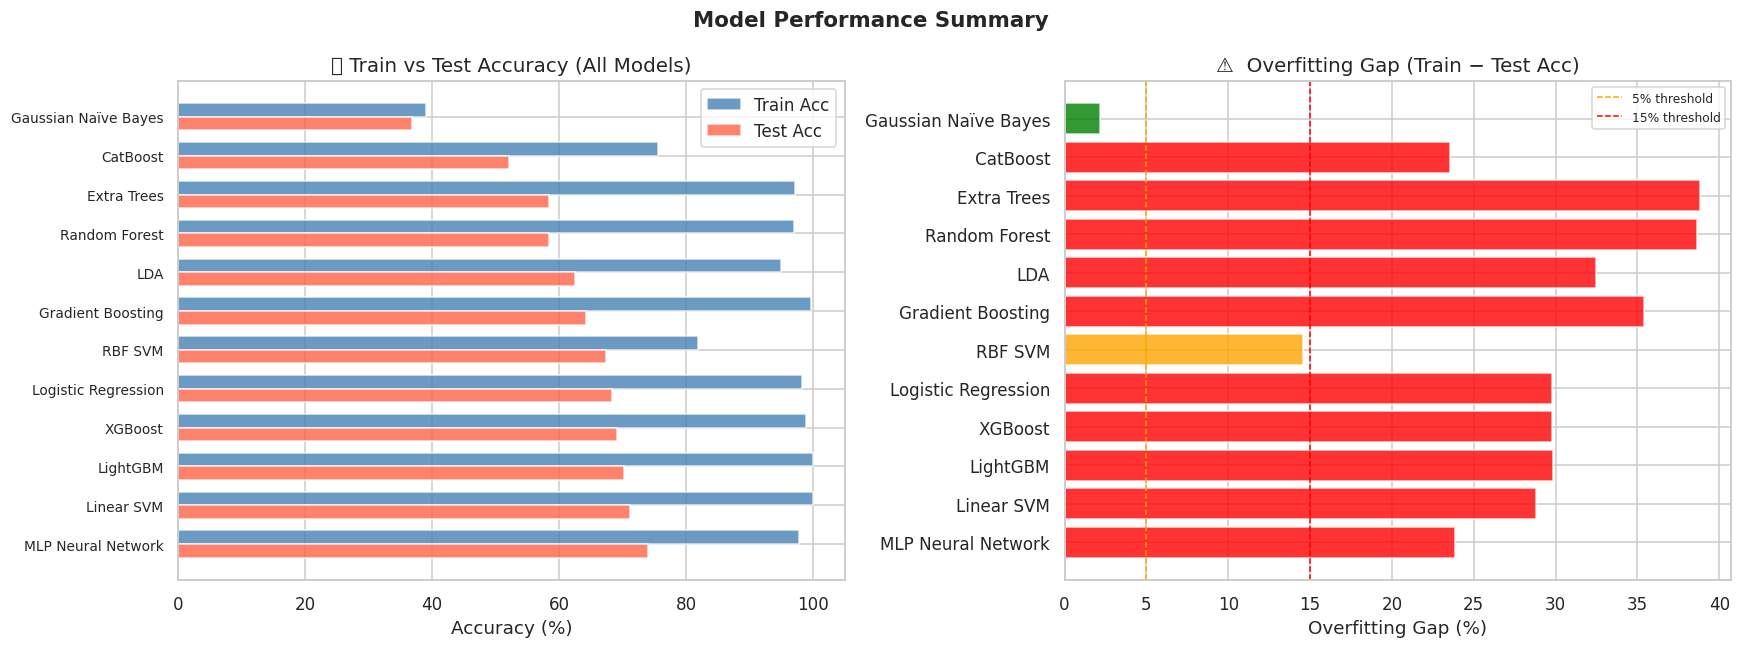


🟢 Green  = well-generalised (<5% gap)
🟠 Orange = mild overfit (5–15% gap)
🔴 Red    = heavy overfit (>15% gap)


In [16]:
# Visual Comparison: Train vs Test Accuracy
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models_ordered = results_df["Model"]
train_accs = results_df["Train Acc"]
test_accs  = results_df["Test Acc"]
gaps       = results_df["Overfit Gap"]

x = np.arange(len(models_ordered))
width = 0.35

axes[0].barh(x + width/2, train_accs * 100, width, label="Train Acc", color="steelblue", alpha=0.8)
axes[0].barh(x - width/2, test_accs  * 100, width, label="Test Acc",  color="tomato",   alpha=0.8)
axes[0].set_yticks(x)
axes[0].set_yticklabels(models_ordered, fontsize=9)
axes[0].set_xlabel("Accuracy (%)")
axes[0].set_title("🏆 Train vs Test Accuracy (All Models)")
axes[0].legend()
axes[0].set_xlim(0, 105)

# Overfitting gap
colors_gap = ["green" if g < 0.05 else "orange" if g < 0.15 else "red" for g in gaps]
axes[1].barh(models_ordered, gaps * 100, color=colors_gap, alpha=0.8)
axes[1].axvline(5,  color="orange", linestyle="--", linewidth=1, label="5% threshold")
axes[1].axvline(15, color="red",    linestyle="--", linewidth=1, label="15% threshold")
axes[1].set_xlabel("Overfitting Gap (%)")
axes[1].set_title("⚠️  Overfitting Gap (Train − Test Acc)")
axes[1].legend(fontsize=8)

plt.suptitle("Model Performance Summary", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🟢 Green  = well-generalised (<5% gap)")
print("🟠 Orange = mild overfit (5–15% gap)")
print("🔴 Red    = heavy overfit (>15% gap)")

The MLP neural network achieved the highest test accuracy (73.96%), indicating that the extracted acoustic features contain complex non-linear relationships that are effectively captured by neural architectures. Linear SVM achieved competitive performance (71.18%), suggesting that the feature space already provides substantial class separability. Ensemble tree-based methods such as Random Forest, Extra Trees, and Gradient Boosting exhibited significant overfitting, achieving near-perfect training accuracy but substantially lower test performance. The poor results of Gaussian Naïve Bayes further indicate strong dependencies among the extracted acoustic features. Overall, the results demonstrate that the proposed feature extraction pipeline provides discriminative information for speech emotion recognition, with neural and margin-based classifiers benefiting most from the learned feature representation.

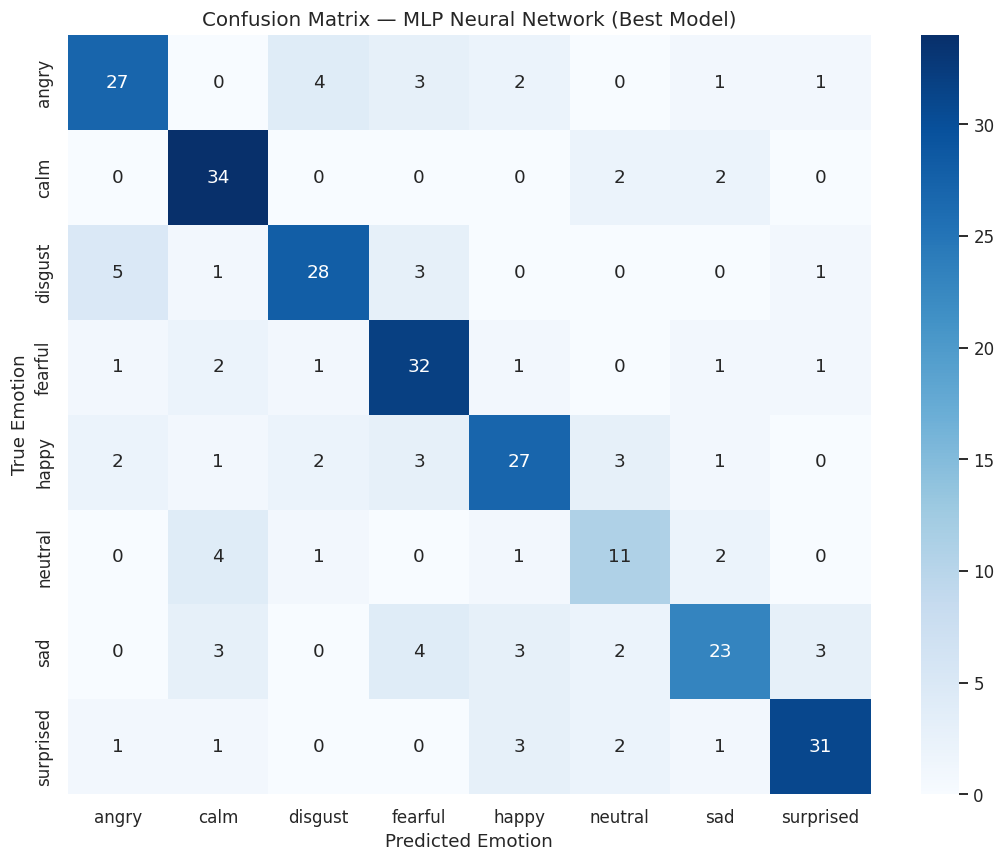


 Classification Report — MLP Neural Network:
              precision    recall  f1-score   support

       angry       0.75      0.71      0.73        38
        calm       0.74      0.89      0.81        38
     disgust       0.78      0.74      0.76        38
     fearful       0.71      0.82      0.76        39
       happy       0.73      0.69      0.71        39
     neutral       0.55      0.58      0.56        19
         sad       0.74      0.61      0.67        38
   surprised       0.84      0.79      0.82        39

    accuracy                           0.74       288
   macro avg       0.73      0.73      0.73       288
weighted avg       0.74      0.74      0.74       288



In [17]:
# Confusion Matrix for Best Model
best_model_name = results_df.iloc[0]["Model"]
best_preds      = all_preds[best_model_name]

cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.title(f"Confusion Matrix — {best_model_name} (Best Model)")
plt.tight_layout()
plt.show()

print(f"\n Classification Report — {best_model_name}:")
print(classification_report(y_test, best_preds, target_names=le.classes_))

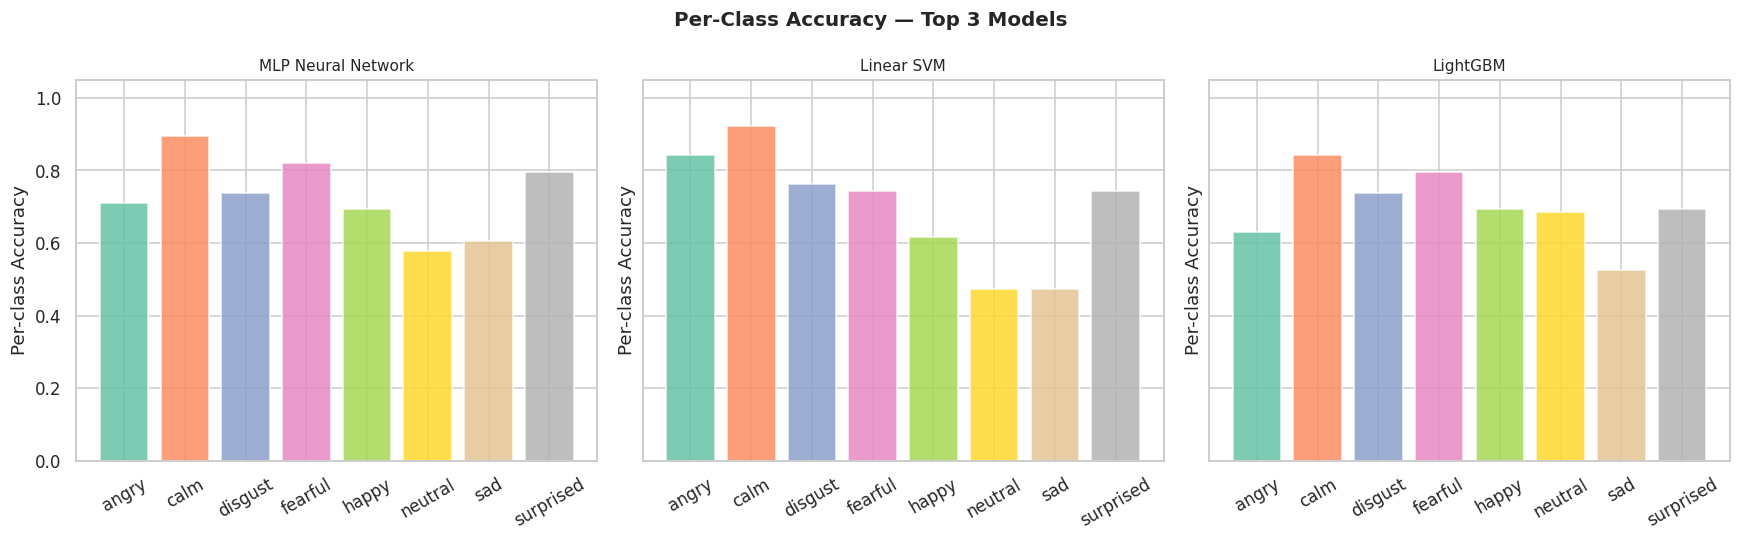

In [18]:
# Per-class accuracy for top 3 models
top3 = results_df.head(3)["Model"].tolist()

fig, axes = plt.subplots(1, len(top3), figsize=(16, 5), sharey=True)

for ax, name in zip(axes, top3):
    preds = all_preds[name]
    per_class_acc = []
    for cls_idx in range(len(le.classes_)):
        mask = (y_test == cls_idx)
        acc  = accuracy_score(y_test[mask], preds[mask]) if mask.sum() > 0 else 0
        per_class_acc.append(acc)

    ax.bar(le.classes_, per_class_acc,
           color=sns.color_palette("Set2", len(le.classes_)), alpha=0.85)
    ax.set_title(f"{name}", fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylabel("Per-class Accuracy")

plt.suptitle("Per-Class Accuracy — Top 3 Models", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**The MLP classifier achieved an overall test accuracy of 73.96% with a macro F1-score of 0.73. The highest-performing classes were surprised (F1 = 0.82) and calm (F1 = 0.81), indicating that these emotions possess distinctive acoustic signatures in the extracted feature space. The primary source of error was the sad class (recall = 0.61), which was frequently confused with fearful and other low-arousal emotions. Similarly, neutral samples were often misclassified as calm. These confusion patterns suggest that while MFCC, Mel-spectrogram, and spectral features effectively capture energy- and timbre-related emotional cues, additional prosodic features such as pitch statistics and speaking-rate measures may further improve discrimination between acoustically similar emotions.**